# 熵权法-TOPSIS 综合评价模型：完整流程与代码实现

> 评价类模型——熵权法 & TOPSIS 整理笔记

核心思想：
- 熵权法解决"权重怎么定"——利用数据离散程度客观赋权
- TOPSIS解决"怎么排序"——通过计算与理想解的距离排序

适用场景：综合评价、方案优选、多指标决策问题。

基本框架：
$$\text{评价对象+指标+权重} \xrightarrow{\text{熵权法}} \text{加权矩阵} \xrightarrow{\text{TOPSIS}} \text{排序}$$


## 目录

| 章节 | 内容 |
|:---:|------|
| 一 | 数据预处理：正向化、标准化 |
| 二 | 熵权法：四步计算流程 |
| 三 | TOPSIS法：理想解、相对贴近度 |
| 四 | 完整流程实战(6城区x10指标) |
| 五 | 可视化展示 |
| 六 | 进阶拓展：组合权重、灰色关联、CRITIC |
| 七 | 模型对比与总结 |


## 准备工作：案例数据

6个城区的公共交通绿色发展评价，10项指标。

| 城区 | 覆盖率 | 候车时间 | 准点率 | 新能源 | 万人车 | 碳排放 | 客运量 | 成本 | 满意度 | 事故数 |
|------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 中心城区 | 96 | 5.2 | 88 | 72 | 18.5 | 0.052 | 3250 | 860 | 86 | 0.21 |
| 东部新区 | 88 | 7.0 | 92 | 91 | 14.2 | 0.038 | 1850 | 780 | 90 | 0.16 |
| 西部工业区 | 75 | 9.5 | 82 | 58 | 11.8 | 0.071 | 2100 | 720 | 76 | 0.29 |
| 北部大学城 | 91 | 6.0 | 90 | 84 | 16.0 | 0.044 | 2400 | 810 | 92 | 0.13 |
| 南部居住区 | 84 | 6.8 | 86 | 76 | 15.1 | 0.049 | 2750 | 750 | 88 | 0.18 |
| 临港新城 | 70 | 10.2 | 94 | 96 | 10.5 | 0.034 | 1200 | 690 | 84 | 0.12 |


In [1]:
# 导入库
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize']=(10,5); plt.rcParams['figure.dpi']=120
np.random.seed(42); print("所有库导入成功")


所有库导入成功


In [2]:
# 加载数据
cities=["中心城区","东部新区","西部工业区","北部大学城","南部居住区","临港新城"]
indicators=["覆盖率_pct","候车时间_min","准点率_pct","新能源占比_pct","万人车辆数",
  "碳排放_kgppkm","客运量_万人次","运营成本_元","满意度_score","事故数"]
indicator_types=["benefit","cost","benefit","benefit","benefit",
  "cost","benefit","cost","benefit","cost"]
raw_data=np.array([[96,5.2,88,72,18.5,0.052,3250,860,86,0.21],
  [88,7.0,92,91,14.2,0.038,1850,780,90,0.16],
  [75,9.5,82,58,11.8,0.071,2100,720,76,0.29],
  [91,6.0,90,84,16.0,0.044,2400,810,92,0.13],
  [84,6.8,86,76,15.1,0.049,2750,750,88,0.18],
  [70,10.2,94,96,10.5,0.034,1200,690,84,0.12]],dtype=float)
raw_df=pd.DataFrame(raw_data,index=cities,columns=indicators)
print("原始数据:"); display(raw_df)


原始数据:


,覆盖率_pct,候车时间_min,准点率_pct,新能源占比_pct,万人车辆数,碳排放_kgppkm,客运量_万人次,运营成本_元,满意度_score,事故数
中心城区,96.0,5.2,88.0,72.0,18.5,0.052,3250.0,860.0,86.0,0.21
东部新区,88.0,7.0,92.0,91.0,14.2,0.038,1850.0,780.0,90.0,0.16
西部工业区,75.0,9.5,82.0,58.0,11.8,0.071,2100.0,720.0,76.0,0.29
北部大学城,91.0,6.0,90.0,84.0,16.0,0.044,2400.0,810.0,92.0,0.13
南部居住区,84.0,6.8,86.0,76.0,15.1,0.049,2750.0,750.0,88.0,0.18
临港新城,70.0,10.2,94.0,96.0,10.5,0.034,1200.0,690.0,84.0,0.12


---
# 一、数据预处理

数据预处理是熵权法-TOPSIS的基础且关键的一步，论文中必须详细说明。

## 1.1 预处理的三个核心任务

| 任务 | 目的 | 方法 |
|------|------|------|
| 正向化 | 统一为越大越好 | 差值法/倒数法 |
| 标准化 | 消除量纲 | 极差/Z-score/向量归一化 |
| 非负平移 | 确保对数有定义 | $+\varepsilon$（如 $10^{-6}$） |

处理顺序：先正向化、再标准化、最后检查是否需要平移。

<span style="color:#c0392b">关键提醒：标准化后数据必须为正数；若出现 $0$，需微小平移，确保熵权法中对数有定义。</span>

## 1.2 正向化处理

评价指标按方向分为四类，需统一转换为极大型：

### (1) 极大型指标(benefit)
不需要转换，原值越大越好。

### (2) 极小型指标(cost)
常用差值法：$x' = \max(x) - x$，或倒数法：$x' = \dfrac{1}{x}$（当 $x > 0$ 时）。差值法更常用。

### (3) 中间型指标
存在最优值 $x_{best}$，越接近越好：$x' = 1 - \dfrac{|x - x_{best}|}{\max(|x - x_{best}|)}$

### (4) 区间型指标
存在最优区间 $[a, b]$，区间内最优，超出区间越远越差。

本案例只有极大型和极小型，对极小型指标做差值法转换。

In [3]:
# 正向化处理：将所有指标统一为极大型
def forward_transform(data, types):
    X=data.astype(float).copy()
    for j in range(X.shape[1]):
        if types[j]=="cost": X[:,j]=X[:,j].max()-X[:,j]
    return X

X_positive=forward_transform(raw_data,indicator_types)
print("正向化后:"); display(pd.DataFrame(X_positive,index=cities,columns=indicators).round(3))


正向化后:


,覆盖率_pct,候车时间_min,准点率_pct,新能源占比_pct,万人车辆数,碳排放_kgppkm,客运量_万人次,运营成本_元,满意度_score,事故数
中心城区,96.0,5.0,88.0,72.0,18.5,0.019,3250.0,0.0,86.0,0.08
东部新区,88.0,3.2,92.0,91.0,14.2,0.033,1850.0,80.0,90.0,0.13
西部工业区,75.0,0.7,82.0,58.0,11.8,0.000,2100.0,140.0,76.0,0.00
北部大学城,91.0,4.2,90.0,84.0,16.0,0.027,2400.0,50.0,92.0,0.16
南部居住区,84.0,3.4,86.0,76.0,15.1,0.022,2750.0,110.0,88.0,0.11
临港新城,70.0,0.0,94.0,96.0,10.5,0.037,1200.0,170.0,84.0,0.17


## 1.3 标准化处理（无量纲化）

### 三种常用方法

| 方法 | 公式 | 范围 |
|------|------|:---:|
| 极差标准化 | $x' = \dfrac{x - \min(x)}{\max(x) - \min(x)}$ | $[0, 1]$ |
| Z-score | $x' = \dfrac{x - \mu}{\sigma}$ | $\mathbb{R}$ |
| 向量归一化 | $x' = \dfrac{x}{\sqrt{\sum x^2}}$ | $(0, 1]$ |

熵权法要求数据必须为正（因需取对数 $\ln(p_{ij})$），推荐极差标准化。若出现 0 需整体平移。

In [4]:
# 标准化处理
def minmax_norm(X):
    X=np.asarray(X,dtype=float)
    d=X.max(0)-X.min(0); d[d==0]=1.0
    return (X-X.min(0))/d

def shift_pos(X,eps=1e-6):
    if np.any(X<=0):
        print(f"[平移]+{eps}"); return X+eps
    return X

X_norm=shift_pos(minmax_norm(X_positive))
print("极差标准化后:"); display(pd.DataFrame(X_norm,index=cities,columns=indicators).round(4))


[平移]+1e-06
极差标准化后:


,覆盖率_pct,候车时间_min,准点率_pct,新能源占比_pct,万人车辆数,碳排放_kgppkm,客运量_万人次,运营成本_元,满意度_score,事故数
中心城区,1.0000,1.00,0.5000,0.3684,1.0000,0.5135,1.0000,0.0000,0.625,0.4706
东部新区,0.6923,0.64,0.8333,0.8684,0.4625,0.8919,0.3171,0.4706,0.875,0.7647
西部工业区,0.1923,0.14,0.0000,0.0000,0.1625,0.0000,0.4390,0.8235,0.000,0.0000
北部大学城,0.8077,0.84,0.6667,0.6842,0.6875,0.7297,0.5854,0.2941,1.000,0.9412
南部居住区,0.5385,0.68,0.3333,0.4737,0.5750,0.5946,0.7561,0.6471,0.750,0.6471
临港新城,0.0000,0.00,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.500,1.0000


---
# 二、熵权法(Entropy Weight Method)

## 2.1 核心直觉

熵是信息论中度量不确定性的概念：
$$\text{数据越离散} \rightarrow \text{信息量越大} \rightarrow \text{熵值越小} \rightarrow \text{权重越大}$$

熵权法用数据的差距性反推指标的重要性。

## 2.2 计算流程(四步法)
设标准化矩阵为 $X = (x_{ij})_{n \times m}$，其中 $n$ 为方案数，$m$ 为指标数。

### 步骤一：计算比重 $p_{ij}$

$$p_{ij} = \frac{x_{ij}}{\sum_{i=1}^{n} x_{ij}}$$

把每列看作概率分布，$p_{ij}$ 表示方案 $i$ 在指标 $j$ 上的相对占比。

### 步骤二：计算熵值 $e_j$

$$e_j = -k \sum_{i=1}^{n} p_{ij} \ln(p_{ij}), \quad k = \frac{1}{\ln(n)} > 0$$

$k = \dfrac{1}{\ln(n)}$ 确保 $0 \leq e_j \leq 1$。当 $p_{ij} = 0$ 时，规定 $p_{ij}\ln(p_{ij}) = 0$（即 $\lim_{p \to 0^+} p\ln p = 0$）。

### 步骤三：信息效用值 $d_j$

$$d_j = 1 - e_j$$

$d_j$ 反映指标信息量：熵值越小，$d_j$ 越大，信息越多。

### 步骤四：归一化得权重 $w_j$

$$w_j = \frac{d_j}{\sum_{j=1}^{m} d_j}, \quad \sum_{j=1}^{m} w_j = 1$$

权重 $w_j$ 完全由数据客观决定。

In [5]:
# 熵权法完整实现(四步法)
def entropy_weight(X):
    """熵权法。输入:(n,m)标准化矩阵(>0)，返回:权重w,中间结果"""
    X=np.asarray(X,dtype=float); n,m=X.shape
    if np.any(X<=0): raise ValueError("存在非正值!")
    
    # 步骤一：比重
    p=X/X.sum(axis=0)
    
    # 步骤二：熵值
    k=1.0/np.log(n)
    plnp=np.where(p>0,p*np.log(p),0.0)
    e=-k*plnp.sum(axis=0)
    
    # 步骤三：信息效用值
    d=1.0-e
    
    # 步骤四：归一化权重
    w=d/d.sum()
    
    return w,{"p":p,"e":e,"d":d,"k":k}

w_entropy,ew_info=entropy_weight(X_norm)
print("="*50); print("熵权法计算结果"); print(f"k=1/ln({len(cities)})={ew_info["k"]:.4f}")
ew_result=pd.DataFrame({"指标":indicators,"类型":indicator_types,
  "熵值e_j":ew_info["e"].round(4),"信息效用d_j":ew_info["d"].round(4),
  "权重w_j":w_entropy.round(4)}).sort_values("权重w_j",ascending=False)
print(ew_result.to_string()); print(f"\n权重总和:{w_entropy.sum():.6f}")


熵权法计算结果
k=1/ln(6)=0.5581
           指标       类型   熵值e_j  信息效用d_j   权重w_j
4       万人车辆数  benefit  0.8291   0.1709  0.1204
1    候车时间_min     cost  0.8303   0.1697  0.1196
0     覆盖率_pct  benefit  0.8406   0.1594  0.1123
7      运营成本_元     cost  0.8547   0.1453  0.1023
6     客运量_万人次  benefit  0.8563   0.1437  0.1012
2     准点率_pct  benefit  0.8620   0.1380  0.0972
3   新能源占比_pct  benefit  0.8636   0.1364  0.0961
9         事故数     cost  0.8797   0.1203  0.0848
5  碳排放_kgppkm     cost  0.8818   0.1182  0.0833
8   满意度_score  benefit  0.8825   0.1175  0.0828

权重总和:1.000000


## 2.3 结果解读与局限性

1.权重最大的指标=离散程度最大的指标
2.权重最小的指标=数据最均匀的指标
3.权重完全由数据驱动，客观性强

| 局限 | 说明 |
|------|------|
| 样本敏感 | 增减方案会改变权重 |
| 忽略含义 | 可能给噪声指标赋高权重 |
| 相关性干扰 | 高度相关指标组平分权重 |

竞赛建议：熵权法常与主观权重(AHP)结合，取组合权重。


---
# 三、TOPSIS法(逼近理想解排序法)

TOPSIS由Hwang & Yoon(1981)提出：最优方案应最接近理想解，同时最远离负理想解。

## 3.1 核心概念

### 理想解与负理想解
加权标准化矩阵 $Z = (z_{ij})_{n \times m}$，其中 $z_{ij} = w_j \cdot x_{ij}$：

$$Z^+=(\max_i z_{i1},\ldots,\max_i z_{im})$$
$$Z^-=(\min_i z_{i1},\ldots,\min_i z_{im})$$

### 欧氏距离
$$D_i^+=\sqrt{\sum_{j=1}^{m}(z_{ij}-z_j^+)^2}$$
$$D_i^-=\sqrt{\sum_{j=1}^{m}(z_{ij}-z_j^-)^2}$$

### 相对贴近度
$$C_i=\frac{D_i^-}{D_i^++D_i^-},\quad 0\leq C_i\leq 1$$

$C_i$ 越大方案越优。$C_i \to 1$ 表示接近理想解；$C_i \to 0$ 表示接近负理想解。

In [6]:
# TOPSIS法完整实现
def topsis(X_norm,weights):
    """TOPSIS。输入:标准化矩阵X(n,m),权重w(m,) 返回:贴近度C(n,)"""
    X=np.asarray(X_norm,dtype=float); w=np.asarray(weights).ravel()
    
    # 1.加权矩阵
    Z=X*w
    
    # 2.理想解/负理想解(已正向化,越大越好)
    Z_plus=Z.max(axis=0); Z_minus=Z.min(axis=0)
    
    # 3.欧氏距离
    D_plus=np.sqrt(((Z-Z_plus)**2).sum(axis=1))
    D_minus=np.sqrt(((Z-Z_minus)**2).sum(axis=1))
    
    # 4.相对贴近度
    denom=D_plus+D_minus; denom[denom==0]=1e-10
    C=D_minus/denom
    
    return C,{"Z":Z,"Z_plus":Z_plus,"Z_minus":Z_minus,"D_plus":D_plus,"D_minus":D_minus}

C_scores,topsis_info=topsis(X_norm,w_entropy)
print("=== TOPSIS评价结果 ===")
result=pd.DataFrame({"城区":cities,"D+":topsis_info["D_plus"].round(4),
  "D-":topsis_info["D_minus"].round(4),"贴近度C":C_scores.round(4)})
result=result.sort_values("贴近度C",ascending=False).reset_index(drop=True)
result["排名"]=range(1,len(result)+1); print(result.to_string())


=== TOPSIS评价结果 ===
      城区      D+      D-    贴近度C  排名
0  北部大学城  0.1083  0.2346  0.6841   1
1   东部新区  0.1263  0.2164  0.6314   2
2   中心城区  0.1454  0.2477  0.6301   3
3  南部居住区  0.1338  0.1943  0.5921   4
4   临港新城  0.2310  0.2121  0.4787   5
5  西部工业区  0.2687  0.1010  0.2733   6


---
# 四、完整流程实战

将数据预处理、熵权法、TOPSIS串联为端到端流程，便于迁移到其他问题。


In [7]:
# 熵权法-TOPSIS完整流程(一键式封装)
def entropy_topsis_pipeline(raw_data,indicator_types,names=None,indicator_names=None,norm_method="minmax"):
    """完整流程。只需修改raw_data,indicator_types,names,indicator_names即可迁移使用。"""
    n,m=raw_data.shape
    if names is None: names=[f"方案{i+1}" for i in range(n)]
    if indicator_names is None: indicator_names=[f"指标{j+1}" for j in range(m)]
    
    # 第一步：正向化
    X_pos=forward_transform(raw_data,indicator_types)
    
    # 第二步：标准化
    if norm_method=="minmax": X_norm=minmax_norm(X_pos)
    else: X_norm=X_pos/np.sqrt((X_pos**2).sum(axis=0))  # 向量归一化
    X_norm=shift_pos(X_norm)
    
    # 第三步：熵权法
    w,ew_info=entropy_weight(X_norm)
    
    # 第四步：TOPSIS
    C,ti=topsis(X_norm,w)
    
    # 整理输出
    result_df=pd.DataFrame({"方案":names,"D+":ti["D_plus"],"D-":ti["D_minus"],"贴近度C":C})
    result_df=result_df.sort_values("贴近度C",ascending=False).reset_index(drop=True)
    result_df["排名"]=range(1,len(result_df)+1)
    
    details={"权重":dict(zip(indicator_names,w)),"熵值":dict(zip(indicator_names,ew_info["e"])),
      "信息效用值":dict(zip(indicator_names,ew_info["d"])),"标准化矩阵":X_norm,"加权矩阵":ti["Z"]}
    return result_df,details

final_result,final_details=entropy_topsis_pipeline(raw_data,indicator_types,cities,indicators)
print("="*60); print("  熵权法-TOPSIS综合评价结果"); print("="*60); display(final_result)
print("\n各指标权重:"); wd=pd.DataFrame({"指标":list(final_details["权重"].keys()),
  "权重":[final_details["权重"][k] for k in final_details["权重"]]}).sort_values("权重",ascending=False)
display(wd.round(4))


[平移]+1e-06
  熵权法-TOPSIS综合评价结果


,方案,D+,D-,贴近度C,排名
0,北部大学城,0.108314,0.234562,0.684101,1
1,东部新区,0.126329,0.216437,0.631443,2
2,中心城区,0.145398,0.247716,0.630139,3
3,南部居住区,0.133812,0.194273,0.592142,4
4,临港新城,0.231003,0.212125,0.478700,5
5,西部工业区,0.268665,0.101038,0.273295,6



各指标权重:


,指标,权重
4,万人车辆数,0.1204
1,候车时间_min,0.1196
0,覆盖率_pct,0.1123
7,运营成本_元,0.1023
6,客运量_万人次,0.1012
2,准点率_pct,0.0972
3,新能源占比_pct,0.0961
9,事故数,0.0848
5,碳排放_kgppkm,0.0833
8,满意度_score,0.0828


---
# 五、可视化展示

评价结果的可视化是论文的重要组成部分。


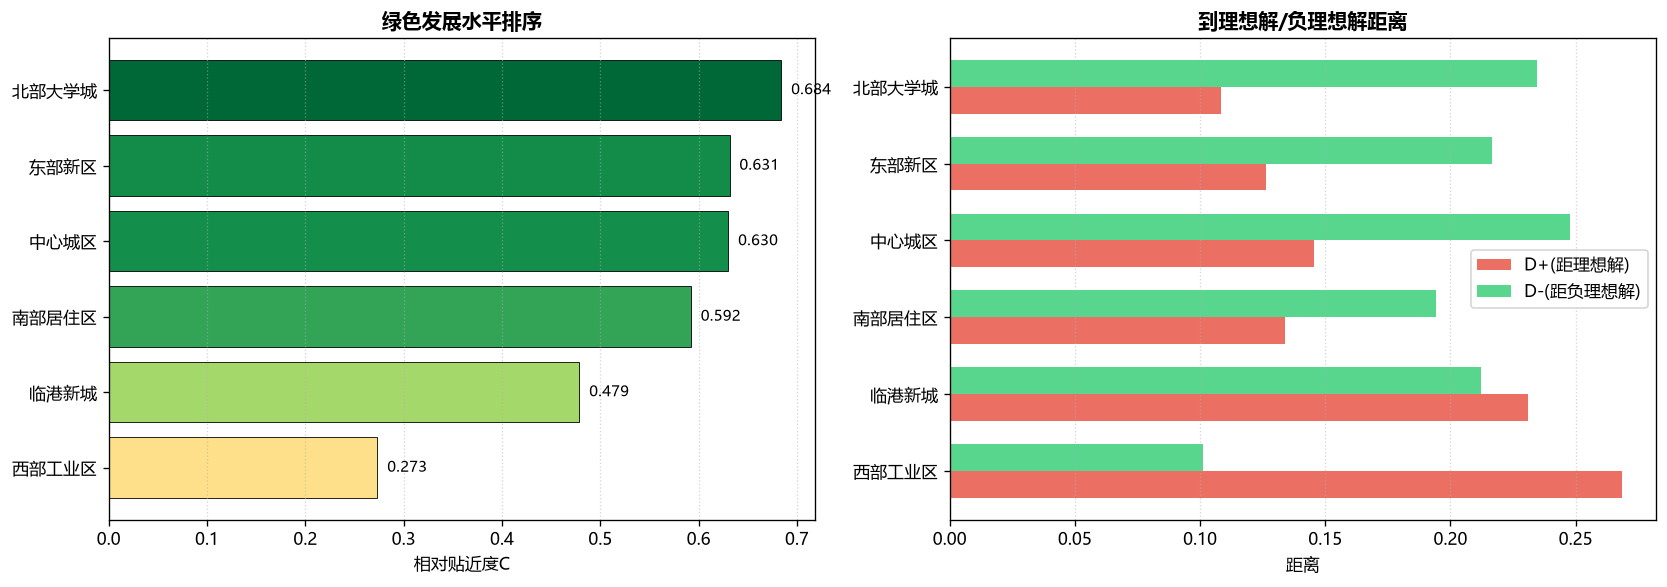

In [8]:
# 5.1 排序条形图
fig,axes=plt.subplots(1,2,figsize=(14,5))
sr=final_result.sort_values("贴近度C",ascending=True)
colors=plt.cm.RdYlGn(sr["贴近度C"]/sr["贴近度C"].max())
axes[0].barh(sr["方案"],sr["贴近度C"],color=colors,edgecolor="black",linewidth=0.5)
axes[0].set_xlabel("相对贴近度C"); axes[0].set_title("绿色发展水平排序",fontweight="bold")
axes[0].grid(axis="x",ls=":",alpha=0.5)
for b,v in zip(axes[0].patches,sr["贴近度C"]):
    axes[0].text(v+0.01,b.get_y()+b.get_height()/2,f"{v:.3f}",va="center",fontsize=9)
x=np.arange(len(sr)); w=0.35
axes[1].barh(x-w/2,sr["D+"],w,label="D+(距理想解)",color="#e74c3c",alpha=0.8)
axes[1].barh(x+w/2,sr["D-"],w,label="D-(距负理想解)",color="#2ecc71",alpha=0.8)
axes[1].set_yticks(x); axes[1].set_yticklabels(sr["方案"])
axes[1].set_xlabel("距离"); axes[1].set_title("到理想解/负理想解距离",fontweight="bold")
axes[1].legend(); axes[1].grid(axis="x",ls=":",alpha=0.5)
plt.tight_layout(); plt.show()


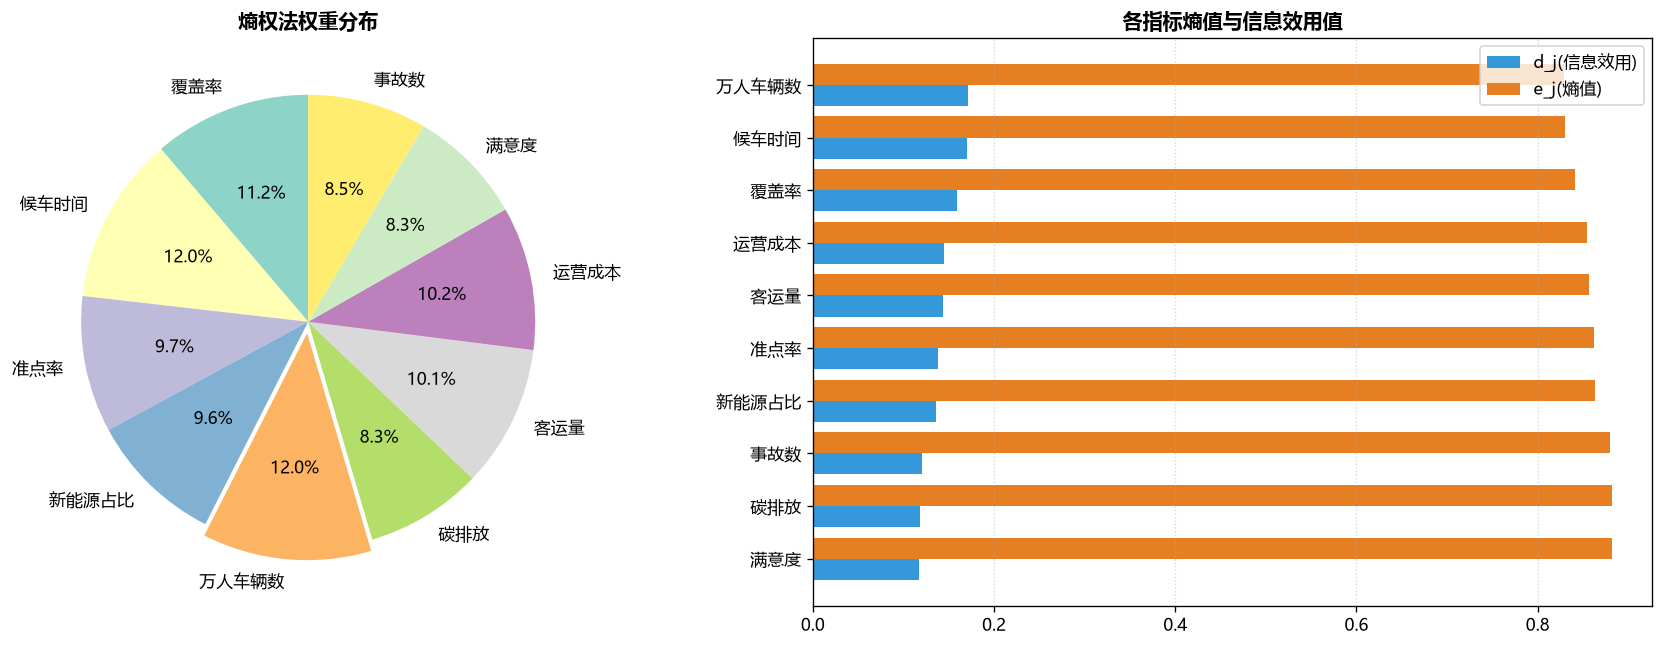

In [9]:
# 5.2 权重饼图+信息效用条形图
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
wd=final_details["权重"]; labs=list(wd.keys()); vals=list(wd.values())
sl=[l.replace("_pct","").replace("_min","").replace("_kgppkm","").replace("_万人次","").replace("_元","").replace("_score","") for l in labs]
expl=[0.05 if v==max(vals) else 0 for v in vals]
axes[0].pie(vals,labels=sl,autopct="%1.1f%%",explode=expl,startangle=90,colors=plt.cm.Set3(np.linspace(0,1,len(vals))))
axes[0].set_title("熵权法权重分布",fontweight="bold")
es=pd.DataFrame({"指标":sl,"e_j":[final_details["熵值"][k] for k in wd],"d_j":[final_details["信息效用值"][k] for k in wd]}).sort_values("d_j")
yp=np.arange(len(es))
axes[1].barh(yp-0.2,es["d_j"],0.4,label="d_j(信息效用)",color="#3498db")
axes[1].barh(yp+0.2,es["e_j"],0.4,label="e_j(熵值)",color="#e67e22")
axes[1].set_yticks(yp); axes[1].set_yticklabels(es["指标"]); axes[1].legend()
axes[1].set_title("各指标熵值与信息效用值",fontweight="bold"); axes[1].grid(axis="x",ls=":",alpha=0.5)
plt.tight_layout(); plt.show()


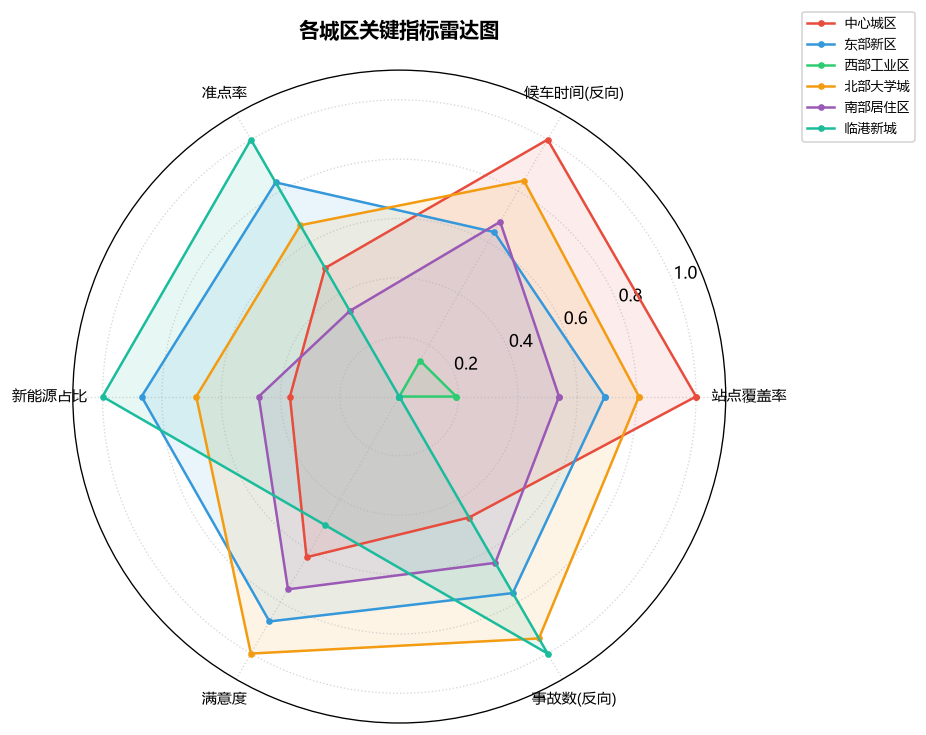

In [10]:
# 5.3 雷达图
ki=[0,1,2,3,8,9]; kl=["站点覆盖率","候车时间(反向)","准点率","新能源占比","满意度","事故数(反向)"]
rd=X_norm[:,ki]; nr=len(ki)
ang=np.linspace(0,2*np.pi,nr,endpoint=False).tolist(); ang+=ang[:1]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
pc=["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6","#1abc9c"]
for i,c in enumerate(cities):
    v=rd[i].tolist(); v+=v[:1]
    ax.fill(ang,v,alpha=0.1,color=pc[i])
    ax.plot(ang,v,"o-",lw=1.5,color=pc[i],label=c,ms=3)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(kl,fontsize=9); ax.set_ylim(0,1.1)
ax.set_title("各城区关键指标雷达图",fontweight="bold",pad=20)
ax.legend(loc="upper right",bbox_to_anchor=(1.3,1.1),fontsize=8); ax.grid(True,ls=":",alpha=0.5)
plt.tight_layout(); plt.show()


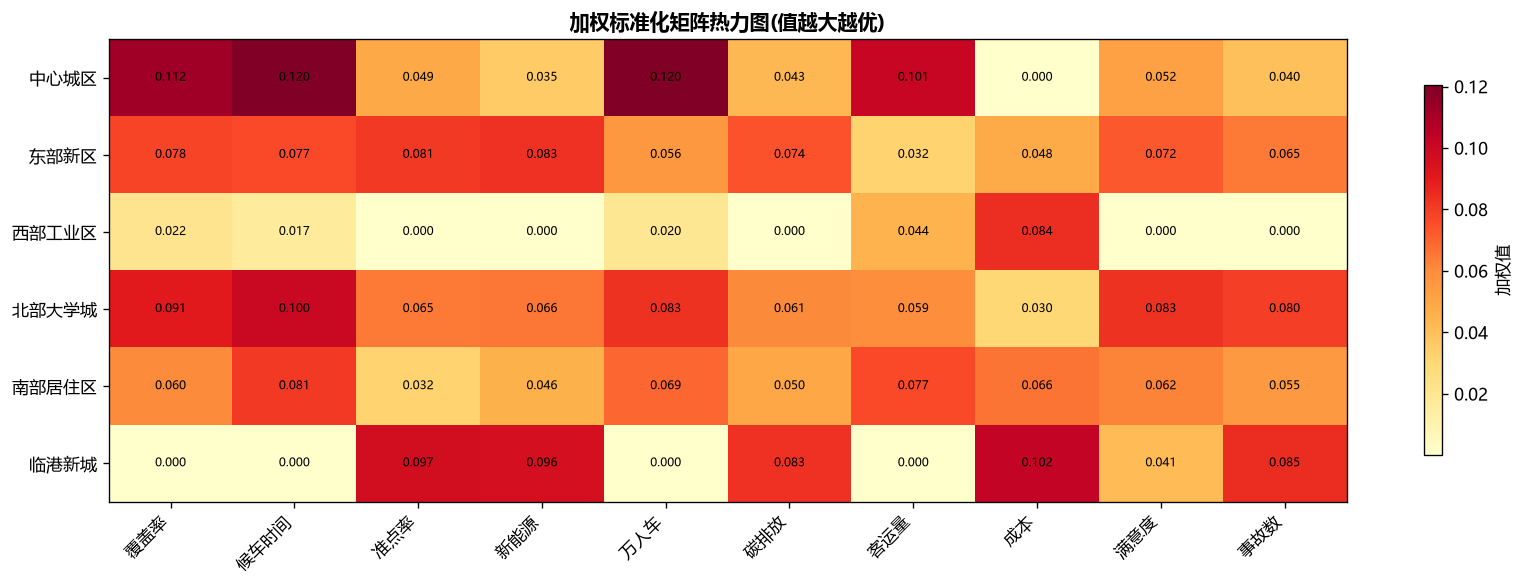

In [11]:
# 5.4 热力图
fig,ax=plt.subplots(figsize=(14,5))
si=["覆盖率","候车时间","准点率","新能源","万人车","碳排放","客运量","成本","满意度","事故数"]
Zm=final_details["加权矩阵"]; im=ax.imshow(Zm,cmap="YlOrRd",aspect="auto")
for i in range(Zm.shape[0]):
    for j in range(Zm.shape[1]):
        ax.text(j,i,f"{Zm[i,j]:.3f}",ha="center",va="center",fontsize=7,color="black" if Zm[i,j]<0.15 else "white")
ax.set_xticks(range(len(si))); ax.set_xticklabels(si,rotation=45,ha="right")
ax.set_yticks(range(len(cities))); ax.set_yticklabels(cities)
ax.set_title("加权标准化矩阵热力图(值越大越优)",fontweight="bold")
plt.colorbar(im,ax=ax,shrink=0.8).set_label("加权值")
plt.tight_layout(); plt.show()


---
# 六、进阶与拓展模型

## 6.1 组合权重：主客观结合

竞赛中常将主观权重(AHP)与客观权重(熵权法)结合：

| 方式 | 公式 | 特点 |
|------|------|------|
| 线性组合 | $w_j = \alpha w_j^{AHP} + (1-\alpha) w_j^{Entropy}$ | $\alpha$ 控制主观占比 |
| 乘法组合 | $w_j = \dfrac{w_j^{AHP} \cdot w_j^{Entropy}}{\sum_{j} w_j^{AHP} \cdot w_j^{Entropy}}$ | 强调共同认可的指标 |

$\alpha = 0.5$ 等权组合最常用。

In [12]:
# 6.1 组合权重
def combine_linear(ws,wo,alpha=0.5):
    w=alpha*np.asarray(ws)+(1-alpha)*np.asarray(wo); return w/w.sum()
def combine_mult(ws,wo):
    w=np.asarray(ws)*np.asarray(wo); return w/w.sum()

# 模拟AHP主观权重
w_ahp=np.array([0.15,0.05,0.10,0.08,0.07,0.15,0.08,0.05,0.18,0.09])
wl=combine_linear(w_ahp,w_entropy,0.5); wm=combine_mult(w_ahp,w_entropy)
si2=["覆盖率","候车时间","准点率","新能源","万人车","碳排放","客运量","成本","满意度","事故数"]
wc=pd.DataFrame({"指标":si2,"AHP":w_ahp.round(4),"熵权":w_entropy.round(4),
  "线性组合":wl.round(4),"乘法组合":wm.round(4)})
print("=== 三种权重方案 ===\n"); print(wc.to_string())

Cc,_=topsis(X_norm,wl)
rc=pd.DataFrame({"城区":cities,"纯熵权":np.argsort(np.argsort(-C_scores))+1,
  "AHP+熵权":np.argsort(np.argsort(-Cc))+1})
print("\n=== 排名对比 ===\n"); print(rc.to_string())


=== 三种权重方案 ===

     指标   AHP      熵权    线性组合    乘法组合
0   覆盖率  0.15  0.1123  0.1311  0.1738
1  候车时间  0.05  0.1196  0.0848  0.0617
2   准点率  0.10  0.0972  0.0986  0.1004
3   新能源  0.08  0.0961  0.0880  0.0793
4   万人车  0.07  0.1204  0.0952  0.0870
5   碳排放  0.15  0.0833  0.1166  0.1289
6   客运量  0.08  0.1012  0.0906  0.0836
7    成本  0.05  0.1023  0.0762  0.0528
8   满意度  0.18  0.0828  0.1314  0.1538
9   事故数  0.09  0.0848  0.0874  0.0787

=== 排名对比 ===

      城区  纯熵权  AHP+熵权
0   中心城区    3       3
1   东部新区    2       2
2  西部工业区    6       6
3  北部大学城    1       1
4  南部居住区    4       4
5   临港新城    5       5


## 6.2 灰色关联-TOPSIS

传统TOPSIS只用欧氏距离。灰色关联-TOPSIS结合灰色关联度：
- 欧氏距离：度量数值上的远近
- 灰色关联度：度量变化趋势的相似程度

关联系数：
$$\xi_{ij}^+=\frac{\min_i\min_j|Z_j^+-z_{ij}|+\rho\max_i\max_j|Z_j^+-z_{ij}|}{|Z_j^+-z_{ij}|+\rho\max_i\max_j|Z_j^+-z_{ij}|}$$

灰色关联度：$\gamma_i^+ = \dfrac{1}{m} \sum_{j=1}^{m} \xi_{ij}^+$

融合贴近度：
$$C_i^{GRA}=\frac{S_i^-}{S_i^++S_i^-},\quad S^+=\beta d^++(1-\beta)g^-,\quad S^-=\beta d^-+(1-\beta)g^+$$

In [13]:
# 6.2 灰色关联-TOPSIS
def grey_topsis(X_norm,weights,rho=0.5,beta=0.5):
    X=np.asarray(X_norm,dtype=float); w=np.asarray(weights).ravel()
    Z=X*w; Zp=Z.max(0); Zm=Z.min(0)
    Dp=np.sqrt(((Z-Zp)**2).sum(1)); Dm=np.sqrt(((Z-Zm)**2).sum(1))
    adp=np.abs(Zp-Z); adm=np.abs(Z-Zm)
    xip=(adp.min()+rho*adp.max())/(adp+rho*adp.max()+1e-10)
    xim=(adm.min()+rho*adm.max())/(adm+rho*adm.max()+1e-10)
    gp=xip.mean(1); gm=xim.mean(1)
    Sp=beta*Dp/Dp.max()+(1-beta)*gm/gm.max()
    Sm=beta*Dm/Dm.max()+(1-beta)*gp/gp.max()
    return Sm/(Sp+Sm+1e-10),{"D_plus":Dp,"D_minus":Dm,"gamma_plus":gp}

Cg,gd=grey_topsis(X_norm,w_entropy)
gr=pd.DataFrame({"城区":cities,"TOPSIS_C":C_scores.round(4),
  "TOPSIS_rank":np.argsort(np.argsort(-C_scores))+1,
  "GRA_C":Cg.round(4),"GRA_rank":np.argsort(np.argsort(-Cg))+1}).sort_values("GRA_rank")
print("TOPSIS vs 灰色关联-TOPSIS\n"); print(gr.to_string())


TOPSIS vs 灰色关联-TOPSIS

      城区  TOPSIS_C  TOPSIS_rank   GRA_C  GRA_rank
3  北部大学城    0.6841            1  0.6657         1
1   东部新区    0.6314            2  0.6316         2
0   中心城区    0.6301            3  0.6285         3
4  南部居住区    0.5921            4  0.5934         4
5   临港新城    0.4787            5  0.5238         5
2  西部工业区    0.2733            6  0.3381         6


## 6.3 其他进阶方法

### CRITIC权重法
同时考虑指标内的对比强度（标准差 $\sigma_j$）和指标间的冲突性（$\sum_k (1 - r_{jk})$）：
$$C_j=\sigma_j\sum_{k}(1-r_{jk}),\quad w_j=\frac{C_j}{\sum_j C_j}$$
与熵权法不同的是CRITIC考虑了指标间相关性。

### VIKOR折中排序法
适用于冲突准则：考虑群体效用 $S_i$ 和个体遗憾 $R_i$。
$$Q_i=v\frac{S_i-S_{min}}{S_{max}-S_{min}}+(1-v)\frac{R_i-R_{min}}{R_{max}-R_{min}}$$

### 秩和比法(RSR)
直接对排名加权求和：$RSR_i = \dfrac{1}{m \cdot n} \sum_{j=1}^{m} w_j R_{ij}$，方法简单但损失原始数值信息。

In [14]:
# 6.3 CRITIC权重法
def critic_weight(X_norm):
    X=np.asarray(X_norm,dtype=float)
    sigma=X.std(axis=0,ddof=0)
    corr=np.corrcoef(X.T)
    conflict=np.sum(1.0-np.abs(corr),axis=0)
    C_j=sigma*conflict
    return C_j/C_j.sum(),{"sigma":sigma,"conflict":conflict}

wc2,ci=critic_weight(X_norm)
si3=["覆盖率","候车时间","准点率","新能源","万人车","碳排放","客运量","成本","满意度","事故数"]
wcmp=pd.DataFrame({"指标":si3,"熵权法":w_entropy.round(4),"CRITIC":wc2.round(4),
  "差异":(w_entropy-wc2).round(4)})
print("熵权法 vs CRITIC\n"); print(wcmp.to_string())
print(f"\n权重相关系数:{np.corrcoef(w_entropy,wc2)[0,1]:.4f}")


熵权法 vs CRITIC

     指标     熵权法  CRITIC      差异
0   覆盖率  0.1123  0.1047  0.0076
1  候车时间  0.1196  0.1056  0.0139
2   准点率  0.0972  0.1100 -0.0128
3   新能源  0.0961  0.1004 -0.0044
4   万人车  0.1204  0.0967  0.0237
5   碳排放  0.0833  0.1051 -0.0218
6   客运量  0.1012  0.0801  0.0211
7    成本  0.1023  0.1046 -0.0022
8   满意度  0.0828  0.0817  0.0011
9   事故数  0.0848  0.1110 -0.0263

权重相关系数:0.0865


---
# 七、模型对比与总结

## 7.1 各类评价模型对比

| 模型 | 权重来源 | 核心思想 | 优点 | 缺点 | 适用场景 |
|------|:---:|------|------|------|----------|
| AHP | 主观 | 两两比较 | 体现经验 | 主观性强 | 指标少(<=9) |
| 熵权法 | 客观 | 离散度 | 完全客观 | 忽略含义 | 指标多 |
| CRITIC | 客观 | 离散+相关 | 考虑冲突 | 依赖相关 | 指标相关强 |
| TOPSIS | — | 距离理想解 | 直观 | 依赖权重 | 配合各种赋权 |
| 灰色关联-TOPSIS | — | 距离+形状 | 兼顾趋势 | 计算复杂 | 样本少 |
| VIKOR | — | 群体+个体 | 考虑最差 | 条件严格 | 偏好不明确 |
| RSR | 可带权重 | 秩的加权 | 简单 | 损失信息 | 快速筛选 |

## 7.2 竞赛选题建议

| 题目特征 | 推荐方法 |
|----------|----------|
| 指标少、专家意见明确 | AHP+加权评分 |
| 指标多、客观数据为主 | 熵权-TOPSIS |
| 指标间存在强相关 | CRITIC-TOPSIS |
| 兼顾主客观 | AHP+熵权组合+TOPSIS |
| 样本少、期望稳健 | 灰色关联-TOPSIS |
| 多方法验证 | 多种方法+Borda集成 |

## 7.3 论文写作要点

1.数据处理必须详细说明：正向化理由、标准化方法、是否平移
2.权重结果要解读：哪些指标权重高、为什么
3.排序结果要验证：敏感性分析、与其他方法对比
4.可视化必不可少：至少选2-3种图表
5.结论要落地：给出首选方案、备选方案及决策建议

## 7.4 代码迁移指南

本notebook所有函数均自包含、可独立调用。迁移到新问题只需：
1.修改raw_data为你的数据矩阵
2.修改indicator_types为对应类型列表
3.修改cities(方案名)和indicators(指标名)
4.运行entropy_topsis_pipeline()即可得到完整结果

如需组合权重，额外提供AHP权重向量调用combine_linear()。
